## Feature Importance

### Purpose
Train logistic regression models on the full preprocessed feature set and use
SHAP partition explainers to rank feature importance. The top-ranked features
inform features for downstream use by the Bayesian network models.

### Overview
With ~1.1% fraud prevalence, a naive model ignores the minority class. Two
class-weighting strategies are compared — **standard** (unweighted) vs.
**balanced** — to understand how imbalance affects both performance and the
stability of SHAP attributions. A stratified 50/50 sample (≤500 per class)
is used for SHAP so fraud-class signal isn't drowned out by the majority.
OHE dummy columns are aggregated back to base categorical names before
plotting for human-readable feature granularity.

### Sections
| # | Section | Description |
|---|------|-------------|
| 0 | Read data | Load `features.json` + train/test parquets |
| 1 | Setup Data | Define X/y splits and build stratified SHAP sample |
| 2 | Grouping Logic | Map OHE columns back to base categorical names |
| 3 | Build Masker | Hierarchical-clustering partition masker for SHAP |
| 4 | SHAP Helper | Train model, compute and aggregate SHAP values |
| 5 | Compare Models | Run standard and balanced variants |
| 6 | Evaluate Models | Confusion matrix, classification report, ROC/PR AUC, MCC |
| 7 | Visualization | Beeswarm plots (all samples + fraud-only) for both models |

In [7]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import scipy.cluster.hierarchy as hclust
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score,
)

In [8]:
# 0. Read data
with open("../data/preprocessed/features.json") as f:
    features = json.load(f)

lr_cols = features["feature_sets"]["logistic_regression"]

train = pd.read_parquet("../data/preprocessed/train.parquet")
test  = pd.read_parquet("../data/preprocessed/test.parquet")

In [9]:
# 1. Setup Data
X = train[lr_cols]
y = train["fraud_bool"]
X_test = test[lr_cols]
y_test = test["fraud_bool"]
# Stratified 50/50 sample: equal fraud and non-fraud for stable SHAP values
# A random draw at 1.1% fraud would yield ~11 fraud rows — too few to be meaningful.
_n = min(int((y == 1).sum()), 500)
_fraud_idx    = y[y == 1].sample(n=_n, random_state=42).index
_non_fraud_idx = y[y == 0].sample(n=_n, random_state=42).index
sample_X = X.loc[_fraud_idx.union(_non_fraud_idx)]
sample_y = y.loc[sample_X.index]
counts = sample_y.value_counts().sort_index()
print(f"SHAP sample class balance — 0: {counts[0]}, 1: {counts[1]} ({counts[1] / len(sample_y):.2%} fraud)")

SHAP sample class balance — 0: 500, 1: 500 (50.00% fraud)


In [10]:
# 2. Define Grouping Logic
CAT_COLS = features["categorical"]


def get_feature_groups(columns, cat_cols):
    groups = {}
    for col in columns:
        matched = next((cat for cat in cat_cols if col.startswith(cat + "_")), None)
        key = matched if matched else col
        groups.setdefault(key, []).append(col)
    return groups


feature_groups = get_feature_groups(X.columns, CAT_COLS)

In [12]:
# 3. Build Masker (once — depends only on X, not on model)
dist_matrix = hclust.distance.pdist(X.corr().fillna(0).T, metric="correlation")
masker = shap.maskers.Partition(X, clustering=hclust.ward(dist_matrix))

In [13]:
# 4. Helper to Train and Aggregate SHAP
def get_aggregated_shap(weight_option, masker):
    model = LogisticRegression(max_iter=1000, class_weight=weight_option)
    model.fit(X, y)

    explainer = shap.PartitionExplainer(
        lambda x: model.predict_proba(pd.DataFrame(x, columns=X.columns))[:, 1], masker
    )
    shap_vals = explainer(sample_X)

    # Aggregate OHE columns back to original feature granularity
    shap_df = pd.DataFrame(shap_vals.values, columns=X.columns)
    data_df = sample_X.copy()
    for prefix, cols in feature_groups.items():
        if len(cols) > 1:
            shap_df[prefix] = shap_df[cols].sum(axis=1)
            shap_df = shap_df.drop(columns=cols)
            # Encode active OHE category as an ordinal code for colour axis
            # 0 = baseline (dropped first dummy), 1/2/3… = each active OHE col
            codes = pd.Series(0, index=data_df.index)
            for i, col in enumerate(cols, start=1):
                codes[data_df[col] == 1] = i
            data_df[prefix] = codes.values
            data_df = data_df.drop(columns=cols)

    return shap.Explanation(
        values=shap_df.values,
        base_values=shap_vals.base_values,
        data=data_df.values,
        feature_names=shap_df.columns.tolist(),
    ), model

In [14]:
# 5. Compare Models
print("Training standard model...")
shap_standard, model_standard = get_aggregated_shap(None, masker)

print("Training balanced model...")
shap_balanced, model_balanced = get_aggregated_shap("balanced", masker)

Training standard model...


PartitionExplainer explainer: 1001it [01:03, 13.26it/s]                         


Training balanced model...


PartitionExplainer explainer: 1001it [01:02, 13.48it/s]                         



=== Standard LogReg ===
[[197775     19]
 [  2183     23]]
              precision    recall  f1-score   support

           0     0.9891    0.9999    0.9945    197794
           1     0.5476    0.0104    0.0205      2206

    accuracy                         0.9890    200000
   macro avg     0.7684    0.5052    0.5075    200000
weighted avg     0.9842    0.9890    0.9837    200000

ROC AUC:  0.8835
PR AUC:   0.1444
MCC:      0.0745


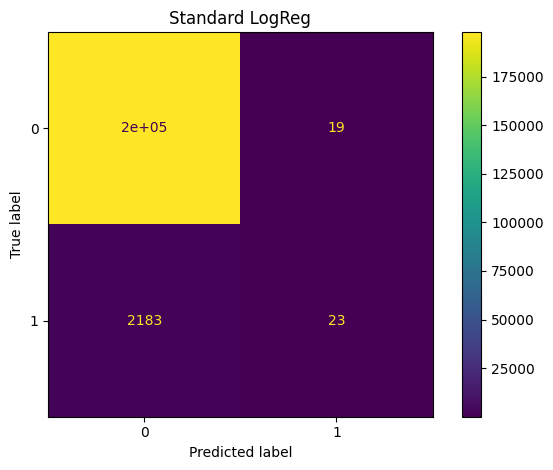


=== Balanced LogReg ===
[[159526  38268]
 [   420   1786]]
              precision    recall  f1-score   support

           0     0.9974    0.8065    0.8919    197794
           1     0.0446    0.8096    0.0845      2206

    accuracy                         0.8066    200000
   macro avg     0.5210    0.8081    0.4882    200000
weighted avg     0.9869    0.8066    0.8829    200000

ROC AUC:  0.8842
PR AUC:   0.1413
MCC:      0.1608


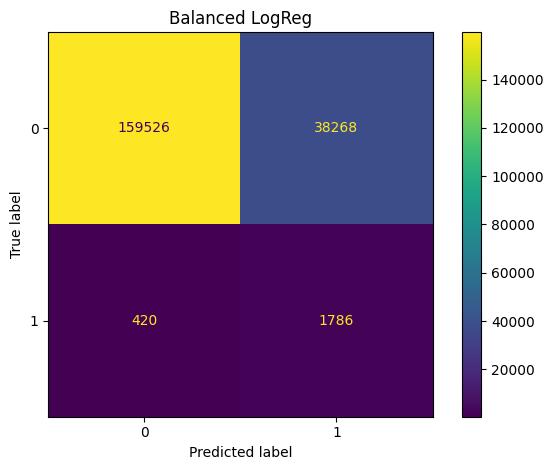

In [15]:
# 6. Evaluate Models
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n=== {name} ===")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=4))
    print(f"ROC AUC:  {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR AUC:   {average_precision_score(y_test, y_proba):.4f}")
    print(f"MCC:      {matthews_corrcoef(y_test, y_pred):.4f}")

    _, ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()


evaluate_model(model_standard, X_test, y_test, "Standard LogReg")
evaluate_model(model_balanced, X_test, y_test, "Balanced LogReg")

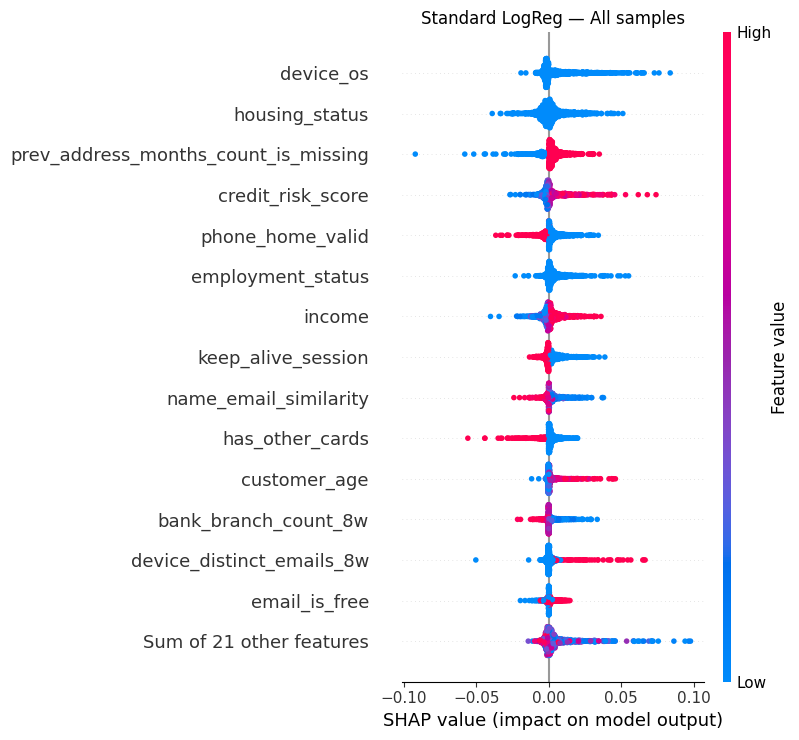

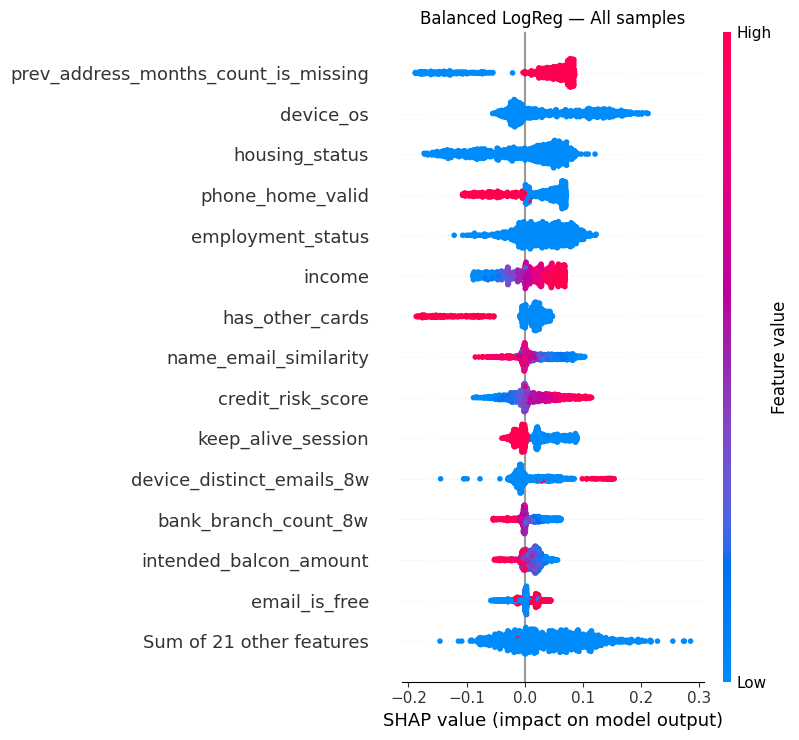

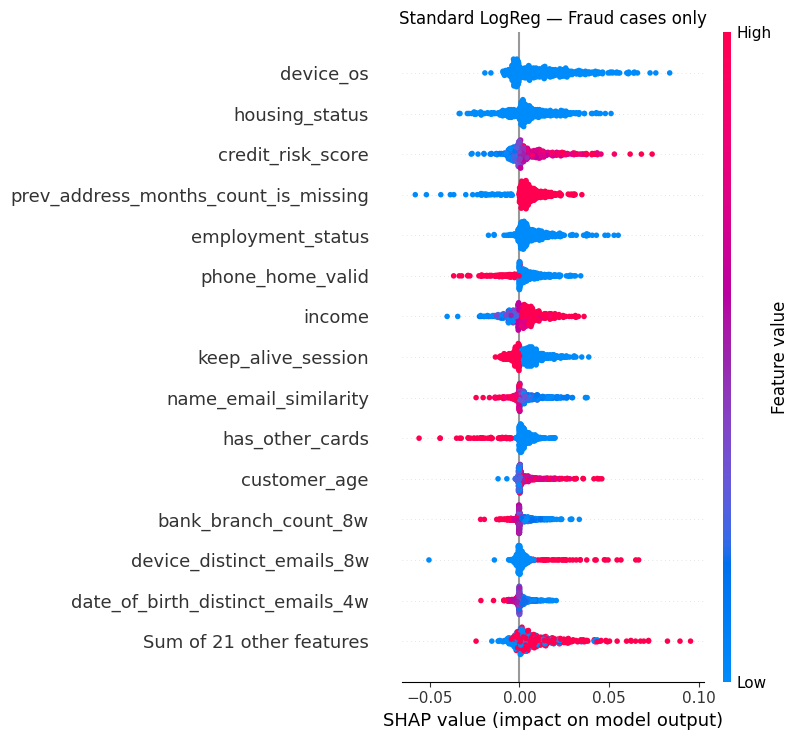

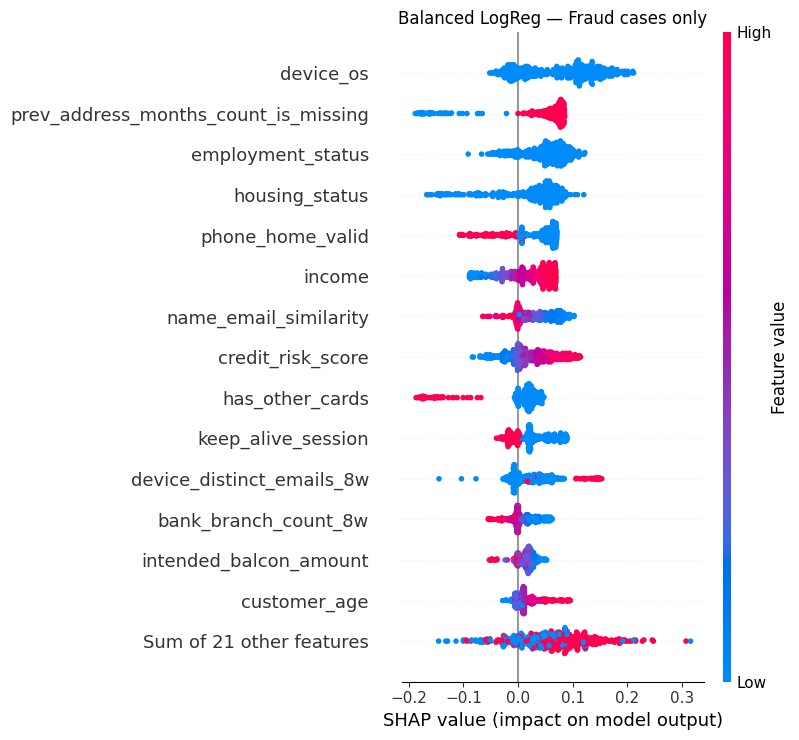

In [ ]:
# 7. Visualization
_fraud_mask = sample_y.values == 1

# Full-sample plots (overall feature importance across both classes)
shap.plots.beeswarm(shap_standard, max_display=15, show=False)
plt.title("Standard LogReg — All samples")
plt.tight_layout()
plt.show()

shap.plots.beeswarm(shap_balanced, max_display=15, show=False)
plt.title("Balanced LogReg — All samples")
plt.tight_layout()
plt.show()

# Fraud-only plots (which features consistently drive fraud predictions)
shap.plots.beeswarm(shap_standard[_fraud_mask], max_display=15, show=False)
plt.title("Standard LogReg — Fraud cases only")
plt.tight_layout()
plt.show()

shap.plots.beeswarm(shap_balanced[_fraud_mask], max_display=15, show=False)
plt.title("Balanced LogReg — Fraud cases only")
plt.tight_layout()
plt.show()